In [4]:
import numpy as np
import torch, pickle, time, os, utils, model
import matplotlib.pyplot as plt


parser = utils.Args('1D Gabor')
parser.add('nonlinearity', 'relu')
parser.add('loss', 'MSE') # MSE or BCE

# model parameters
parser.add('N', 500); parser.add('Nhid', 500); parser.add('n_layers', 1)

# task parameters (make sure these values are floats)
parser.add('sig_w', 0.8); parser.add('sig_s', 0.2); parser.add('theta', np.pi)

# training parameter
parser.add('eta', 1e-1)
parser.add('n_learn', 2000000)
parser.add('n_train_trials', 50)
parser.add('n_test_trials', 2500)  # remember we do 20 copies of this
parser.add('test_interval', 1000)
parser.add('noise_var', 0.01)
parser.add('lambda2', 0.0)  # Aug 16, 2020: added L2 constraint support

args = parser.parse_args()

sigsstim = utils.SigsStimuli(args)


calc_MLD(): MLD error is 0.15865772293105745


In [5]:
"""Set up GPUs. To run locally / on CPUs, set gpu=None."""
gpu = None
if args.cluster == 1:
    gpu = torch.device('cuda:0')


TIC = time.time()  # Start time of the script

mgr = utils.Manager(args, device=gpu); trainer = utils.Trainer(args); stimuli = utils.GaborStimuli(args, device=gpu)

net = model.Model(args, dims=[args.N, *[args.Nhid for i in range(args.n_layers)]])
net = net.to(device=gpu)

get_sigs_task_error(net, sigsstim)

Running in local mode. Run started at 2021-03-18 16:12:52.064737
calc_MLD(): MLD error is 0.1586576904530841


NameError: name 'get_sigs_task_error' is not defined

In [118]:

"""Full training"""

# turn gradient back on
net.RESET_WEIGHTS()
net = net.to(device=gpu)

train_utils.pretrain_readout(network=net, manager=mgr, stimuli=stimuli, loss_type=args.loss)
args.eta = float(args.eta / torch.norm(net.RO.weight).cpu())
for i in range(net.n_layers):
    if i in net.freeze:
        continue
    else:
        net.Ls[i].weight.requires_grad = True

trainer.start_trial(net, stimuli, args, mgr)  # also logs args and time into the data dict in mgr

init_weights = [w.to(gpu) for w in net.init_weights]

all_init_vars = [_p.data.clone() for _p in list(net.parameters())]

sigs_error = []

for step in range(args.n_learn):

    # compute gradients using the chosen loss function
    train_utils.zero_and_grad(net, stimuli, loss_type=args.loss, v_teacher=stimuli.x1_normed.T)

    if step % args.test_interval == 0:

        te_error = 0; te_loss = 0
        for mem_saving_avg in range(20):
            _te_error, _te_loss, divergence_flag = train_utils.test(net, stimuli, loss_type=args.loss, v_teacher=stimuli.x1_normed)
            te_error += _te_error / 20
            te_loss += _te_loss / 20

            if divergence_flag:
                raise RuntimeError('Loss function diverged.')

        #create variables to store

        all_delW, a, all_phi_prime, v_eff = train_utils.create_variables_to_store(stimuli, net, args)

        trainer.report_and_track(list_of_keys=['delW', 'a', 'phi_prime', 'v_eff'],
                                 list_of_vars=[all_delW, a, all_phi_prime, v_eff],
                                 step=step,
                                 test_error=te_error,
                                 test_loss=te_loss)  # also saves data from each test into the hard drive

        if trainer.detect_end_of_training(detect_mld=False, threshold=1e-6):
            break
            
        error = get_sigs_task_error(net, sigsstim)
        sigs_error.append(error)

            
    train_utils.do_update(net, args.eta)
    

    
    
    # apply L2 constraint
    for p, p_init in zip(list(net.parameters()), all_init_vars):
        p.data -= args.eta * args.lambda2 * (p.data - p_init)


changes_to_weights = [_L.weight.data - init_w for _L, init_w in zip(net.Ls, init_weights)]



Readout is "pretrained" using the expression for optimal readout.
Norm of initial a: 32.02267074584961
Pretraining took 0.2 secs.
1/2000000, Error 0.40581, Training Loss 0.01777, Time 1 sec
Data not added since running in local mode.
1001/2000000, Error 0.38341, Training Loss 0.01689, Time 11 sec
Data not added since running in local mode.
2001/2000000, Error 0.37146, Training Loss 0.01623, Time 21 sec
Data not added since running in local mode.
3001/2000000, Error 0.36715, Training Loss 0.01581, Time 31 sec
Data not added since running in local mode.
4001/2000000, Error 0.32513, Training Loss 0.01413, Time 41 sec
Data not added since running in local mode.
5001/2000000, Error 0.31147, Training Loss 0.01323, Time 52 sec
Data not added since running in local mode.
6001/2000000, Error 0.31506, Training Loss 0.01280, Time 62 sec
Data not added since running in local mode.
7001/2000000, Error 0.34540, Training Loss 0.01358, Time 73 sec
Data not added since running in local mode.
8001/20000

KeyboardInterrupt: 

In [110]:
mgr.trial_data_dict.keys()

dict_keys(['time', 'args', 'error', 'loss', 'delW', 'a', 'phi_prime', 'v_eff'])

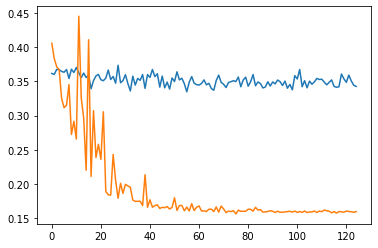

In [119]:
plt.figure()
plt.plot(sigs_error)
plt.plot(mgr.trial_data_dict['error'])

In [ ]:

eff_weights = r_utils.get_effective_weights(net, sigsstim.x0, full_mat=True)[0]
forward_mat = eff_weights[0]
for i in range(len(eff_weights)):
    if i > 0:
        forward_mat = eff_weights[i] @ forward_mat
numpy_a = train_utils.mse_optimal_a(forward_mat, sigsstim, 3)
net.RO.weight.data = torch.FloatTensor(numpy_a).view(1, -1).to(net.RO.weight.device)

        
# train_utils.pretrain_readout(network=net, manager=mgr, stimuli=sigsstim, loss_type=args.loss)


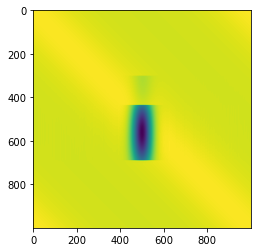

In [94]:
plt.figure()
plt.imshow(net.Ws[0])